# AI and Cybersecurity - Advanced AI labs

In [1]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Cat vs. Dog Image Classification
## Exercise 1: Building a Convnet from Scratch
**_Estimated completion time: 20 minutes_**

In this exercise, we will build a classifier model from scratch that is able to distinguish dogs from cats. We will follow these steps:

1. Explore the example data
2. Build a small convnet from scratch to solve our classification problem
3. Evaluate training and validation accuracy

Let's go!

## Explore the Example Data

Let's start by downloading our example data, a .zip of 2,000 JPG pictures of cats and dogs, and extracting it locally in `/tmp`.

**NOTE:** The 2,000 images used in this exercise are excerpted from the ["Dogs vs. Cats" dataset](https://www.kaggle.com/c/dogs-vs-cats/data) available on Kaggle, which contains 25,000 images. Here, we use a subset of the full dataset to decrease training time for educational purposes.

In [2]:
!wget --no-check-certificate \
    https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip \
    -O /tmp/cats_and_dogs_filtered.zip



7[Files: 0  Bytes: 0  [0 B/s] Re]87WARNING: The certificate is NOT trusted. The certificate issuer is unknown. 
87[https://download.microsoft.com]87Saving '/tmp/cats_and_dogs_filtered.zip'
87[Files: 0  Bytes: 0  [0 B/s] Re]87/tmp/cats_and_dogs_f   8% [=>                            ]   66.03M    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87/tmp/cats_and_dogs_f  16% [====>                         ]  131.77M   65.67MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87/tmp/cats_and_dogs_f  24% [======>                       ]  196.40M   65.14MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87/tmp/cats_and_dogs_f  30% [========>                     ]  238.07M   57.32MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87/tmp/cats_and_dogs_f  37% [==========>                   ]  293.58M   56.87MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87/tmp/cats_and_dogs_f  46% [============>                 ]  362.89M   59.36MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87/tmp/cats_and_dogs_f  54% [===============>     

In [3]:
import os
import zipfile
import cv2

local_zip = '/tmp/cats_and_dogs_filtered.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

The contents of the .zip are extracted to the base directory `/tmp/cats_and_dogs_filtered`, which contains `train` and `validation` subdirectories for the training and validation datasets (see the [Machine Learning Crash Course](https://developers.google.com/machine-learning/crash-course/validation/check-your-intuition) for a refresher on training, validation, and test sets), which in turn each contain `cats` and `dogs` subdirectories. Let's define each of these directories:

In [4]:
base_dir = '/tmp/PetImages'
cat_dir = os.path.join(base_dir, 'Cat')
dog_dir = os.path.join(base_dir, 'Dog')

Now, let's see what the filenames look like in the `cats` and `dogs` `train` directories (file naming conventions are the same in the `validation` directory):

In [5]:
cat_fnames = os.listdir(cat_dir)
print(cat_fnames[:10])

dog_fnames = os.listdir(dog_dir)
print(dog_dir[:10])

['Thumbs.db', '9999.jpg', '9998.jpg', '9997.jpg', '9996.jpg', '9995.jpg', '9994.jpg', '9993.jpg', '9992.jpg', '9991.jpg']
/tmp/PetIm


Let's find out the total number of cat and dog images in the directories:

In [6]:
print('total training cat images:', len(os.listdir(cat_dir)))
print('total training dog images:', len(os.listdir(dog_dir)))


total training cat images: 12501
total training dog images: 12501


In [7]:
import os
import shutil
import random

# Paths
original_dataset_dir = base_dir          # your input folder

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# Create directories
for split in ["train", "test"]:
    for category in ["Cat", "Dog"]:
        os.makedirs(os.path.join(base_dir, split, category), exist_ok=True)

def split_data(category, train_size=2000, test_size=1000):
    src_dir = os.path.join(original_dataset_dir, category)
    images = os.listdir(src_dir)
    train_images = images[:train_size]
    test_images = images[train_size:train_size + test_size]

    # Copy files
    for img in train_images:
        shutil.copy(
            os.path.join(src_dir, img),
            os.path.join(train_dir, category, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(src_dir, img),
            os.path.join(test_dir, category, img)
        )

# Run for both categories
split_data("Cat")
split_data("Dog")

print("Dataset split complete.")

Dataset split complete.


In [8]:
import os


base_dir = '/tmp/PetImages'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'test')

# Directory with our training cat pictures
train_cats_dir = os.path.join(train_dir, 'Cat')

# Directory with our training dog pictures
train_dogs_dir = os.path.join(train_dir, 'Dog')

# Directory with our validation cat pictures
validation_cats_dir = os.path.join(validation_dir, 'Cat')

# Directory with our validation dog pictures
validation_dogs_dir = os.path.join(validation_dir, 'Dog')

train_cat_fnames = os.listdir(train_cats_dir)
print(train_cat_fnames[:10])

train_dog_fnames = os.listdir(train_dogs_dir)
train_dog_fnames.sort()
print(train_dog_fnames[:10])

['82.jpg', '820.jpg', '8200.jpg', '8201.jpg', '8202.jpg', '8203.jpg', '8204.jpg', '8205.jpg', '8206.jpg', '8207.jpg']
['82.jpg', '820.jpg', '8200.jpg', '8201.jpg', '8202.jpg', '8203.jpg', '8204.jpg', '8205.jpg', '8206.jpg', '8207.jpg']


For both cats and dogs, we have 1,000 training images and 500 test images.

Now let's take a look at a few pictures to get a better sense of what the cat and dog datasets look like. First, configure the matplot parameters:

In [9]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Parameters for our graph; we'll output images in a 4x4 configuration
nrows = 4
ncols = 4

# Index for iterating over images
pic_index = 0

Now, display a batch of 8 cat and 8 dog pictures. You can rerun the cell to see a fresh batch each time:

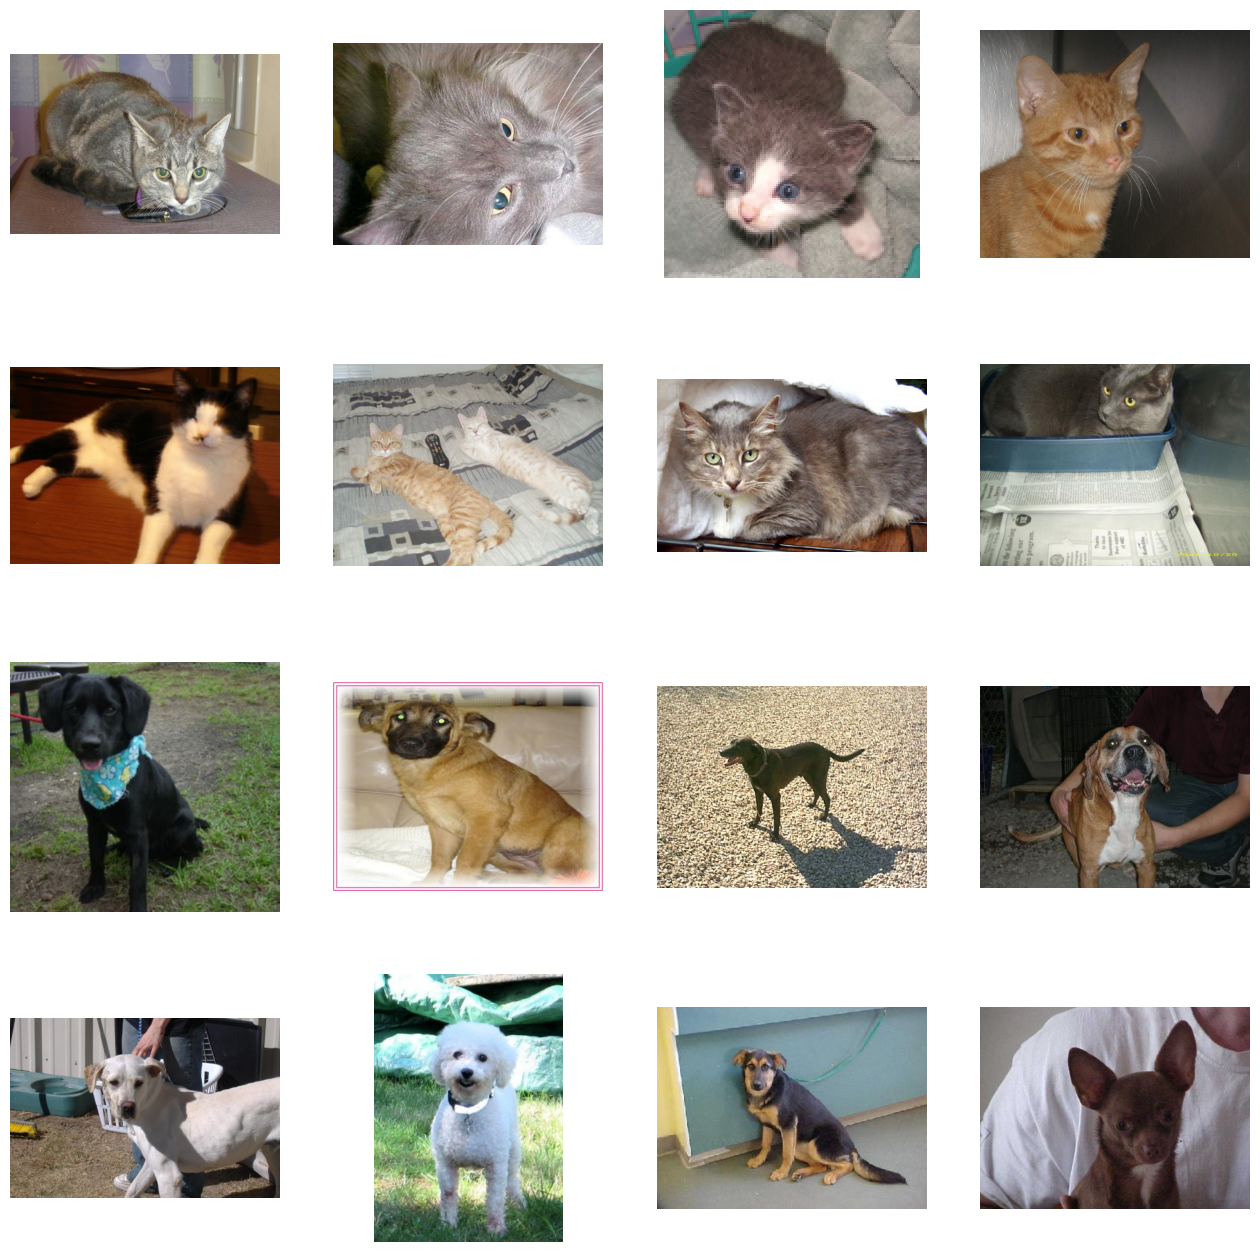

In [10]:
# Set up matplotlib fig, and size it to fit 4x4 pics
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

pic_index += 8
next_cat_pix = [os.path.join(train_cats_dir, fname)
                for fname in train_cat_fnames[pic_index-8:pic_index]]
next_dog_pix = [os.path.join(train_dogs_dir, fname)
                for fname in train_dog_fnames[pic_index-8:pic_index]]

for i, img_path in enumerate(next_cat_pix+next_dog_pix):
  # Set up subplot; subplot indices start at 1
  sp = plt.subplot(nrows, ncols, i + 1)
  sp.axis('Off') # Don't show axes (or gridlines)

  img = mpimg.imread(img_path)
  plt.imshow(img)

plt.show()


## Building a Small Convnet from Scratch to Get to 72% Accuracy

The images that will go into our convnet are 150x150 color images (in the next section on Data Preprocessing, we'll add handling to resize all the images to 150x150 before feeding them into the neural network).

Let's code up the architecture. We will stack 3 {convolution + relu + maxpooling} modules. Our convolutions operate on 3x3 windows and our maxpooling layers operate on 2x2 windows. Our first convolution extracts 16 filters, the following one extracts 32 filters, and the last one extracts 64 filters.

**NOTE**: This is a configuration that is widely used and known to work well for image classification. Also, since we have relatively few training examples (1,000), using just three convolutional modules keeps the model small, which lowers the risk of overfitting (which we'll explore in more depth in Exercise 2.)

In [11]:
!pip install tensorflow
from tensorflow.keras import layers
from tensorflow.keras import Model

I0000 00:00:1776863715.123499  190691 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776863715.124142  190691 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776863715.158031  190691 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776863716.247236  190691 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [12]:
# Our input feature map is 150x150x3: 150x150 for the image pixels, and 3 for
# the three color channels: R, G, and B
img_input = layers.Input(shape=(150, 150, 3))

# First convolution extracts 16 filters that are 3x3
# Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(16, 3, activation='relu')(img_input)
x = layers.MaxPooling2D(2)(x)

# Second convolution extracts 32 filters that are 3x3
# Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

# Third convolution extracts 64 filters that are 3x3
# Convolution is followed by max-pooling layer with a 2x2 window
x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D(2)(x)

E0000 00:00:1776863716.978002  190691 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


On top of it we stick two fully-connected layers. Because we are facing a two-class classification problem, i.e. a *binary classification problem*, we will end our network with a [*sigmoid* activation](https://wikipedia.org/wiki/Sigmoid_function), so that the output of our network will be a single scalar between 0 and 1, encoding the probability that the current image is class 1 (as opposed to class 0).

In [13]:
# Flatten feature map to a 1-dim tensor so we can add fully connected layers
x = layers.Flatten()(x)

# Create a fully connected layer with ReLU activation and 512 hidden units
x = layers.Dense(512, activation='relu')(x)

# Create output layer with a single node and sigmoid activation
output = layers.Dense(1, activation='sigmoid')(x)

# Create model:
# input = input feature map
# output = input feature map + stacked convolution/maxpooling layers + fully
# connected layer + sigmoid output layer
model = Model(img_input, output)

Let's summarize the model architecture:

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

The "output shape" column shows how the size of your feature map evolves in each successive layer. The convolution layers reduce the size of the feature maps by a bit due to padding, and each pooling layer halves the feature map.

Next, we'll configure the specifications for model training. We will train our model with the `binary_crossentropy` loss, because it's a binary classification problem and our final activation is a sigmoid. (For a refresher on loss metrics, see the [Machine Learning Crash Course](https://developers.google.com/machine-learning/crash-course/descending-into-ml/video-lecture).) We will use the `rmsprop` optimizer with a learning rate of `0.001`. During training, we will want to monitor classification accuracy.

**NOTE**: In this case, using the [RMSprop optimization algorithm](https://wikipedia.org/wiki/Stochastic_gradient_descent#RMSProp) is preferable to [stochastic gradient descent](https://developers.google.com/machine-learning/glossary/#SGD) (SGD), because RMSprop automates learning-rate tuning for us. (Other optimizers, such as [Adam](https://wikipedia.org/wiki/Stochastic_gradient_descent#Adam) and [Adagrad](https://developers.google.com/machine-learning/glossary/#AdaGrad), also automatically adapt the learning rate during training, and would work equally well here.)

In [15]:
from tensorflow.keras.optimizers import RMSprop

model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=0.001),
              metrics=['acc'])

### Data Preprocessing

Let's set up data generators that will read pictures in our source folders, convert them to `float32` tensors, and feed them (with their labels) to our network. We'll have one generator for the training images and one for the validation images. Our generators will yield batches of 20 images of size 150x150 and their labels (binary).

As you may already know, data that goes into neural networks should usually be normalized in some way to make it more amenable to processing by the network. (It is uncommon to feed raw pixels into a convnet.) In our case, we will preprocess our images by normalizing the pixel values to be in the `[0, 1]` range (originally all values are in the `[0, 255]` range).

In Keras this can be done via the `keras.preprocessing.image.ImageDataGenerator` class using the `rescale` parameter. This `ImageDataGenerator` class allows you to instantiate generators of augmented image batches (and their labels) via `.flow(data, labels)` or `.flow_from_directory(directory)`. These generators can then be used with the Keras model methods that accept data generators as inputs: `fit_generator`, `evaluate_generator`, and `predict_generator`.

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,  # This is the source directory for training images
        target_size=(150, 150),  # All images will be resized to 150x150
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

# Flow validation images in batches of 20 using val_datagen generator
validation_generator = val_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')



Found 3998 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


### Training
Let's train on all 2,000 images available, for 15 epochs, and validate on all 1,000 validation images. (This may take a few minutes to run.)

In [17]:
history = model.fit(
      train_generator,
      steps_per_epoch=100,  # 2000 images = batch_size * steps
      epochs=15,
      validation_data=validation_generator,
      validation_steps=50,  # 1000 images = batch_size * steps
      verbose=2)

Epoch 1/15


I0000 00:00:1776863717.163886  190691 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


100/100 - 7s - 69ms/step - acc: 0.5580 - loss: 0.6915 - val_acc: 0.6230 - val_loss: 0.6583
Epoch 2/15
100/100 - 6s - 61ms/step - acc: 0.6246 - loss: 0.6483 - val_acc: 0.6390 - val_loss: 0.6427
Epoch 3/15
100/100 - 6s - 63ms/step - acc: 0.6752 - loss: 0.5939 - val_acc: 0.6620 - val_loss: 0.6021
Epoch 4/15
100/100 - 6s - 61ms/step - acc: 0.7285 - loss: 0.5424 - val_acc: 0.6980 - val_loss: 0.5720
Epoch 5/15
100/100 - 6s - 63ms/step - acc: 0.7595 - loss: 0.4967 - val_acc: 0.7400 - val_loss: 0.5403
Epoch 6/15
100/100 - 6s - 62ms/step - acc: 0.7858 - loss: 0.4538 - val_acc: 0.7040 - val_loss: 0.5956
Epoch 7/15
100/100 - 6s - 61ms/step - acc: 0.7998 - loss: 0.4336 - val_acc: 0.7010 - val_loss: 0.5724
Epoch 8/15
100/100 - 6s - 62ms/step - acc: 0.8315 - loss: 0.3748 - val_acc: 0.7170 - val_loss: 0.6440
Epoch 9/15
100/100 - 6s - 63ms/step - acc: 0.8380 - loss: 0.3645 - val_acc: 0.7510 - val_loss: 0.5555
Epoch 10/15
100/100 - 6s - 61ms/step - acc: 0.8719 - loss: 0.3055 - val_acc: 0.7390 - val_los

### Visualizing Intermediate Representations

To get a feel for what kind of features our convnet has learned, one fun thing to do is to visualize how an input gets transformed as it goes through the convnet.

Let's pick a random cat or dog image from the training set, and then generate a figure where each row is the output of a layer, and each image in the row is a specific filter in that output feature map. Rerun this cell to generate intermediate representations for a variety of training images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


/tmp/ipykernel_190691/788551056.py:43: RuntimeWarning: invalid value encountered in divide
  x /= x.std()
/tmp/ipykernel_190691/788551056.py:46: RuntimeWarning: invalid value encountered in cast
  x = np.clip(x, 0, 255).astype('uint8')


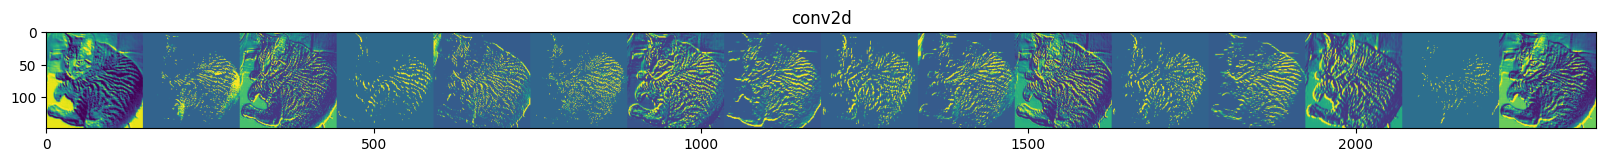

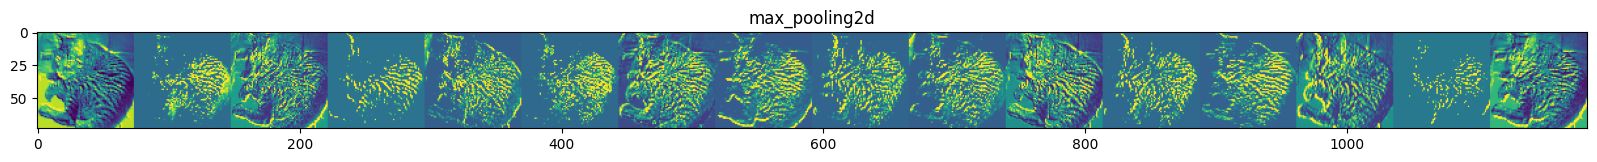

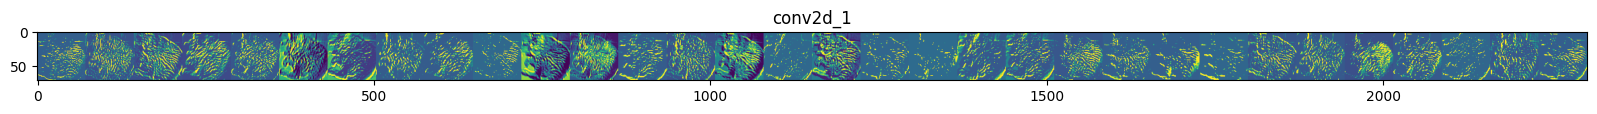

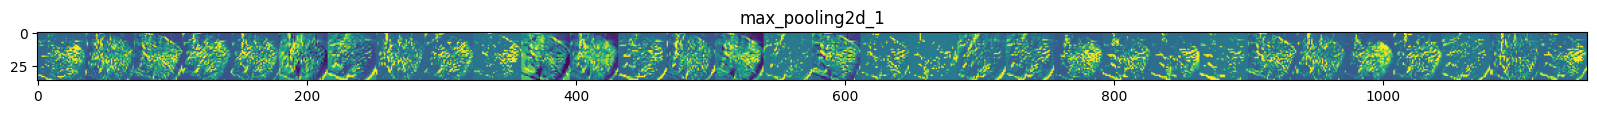

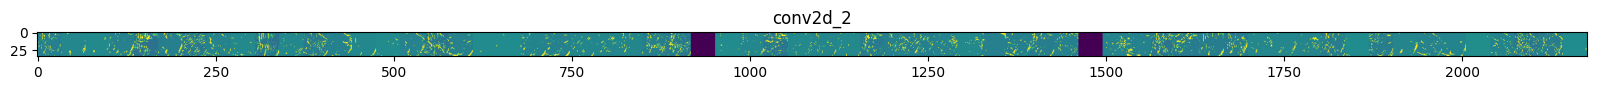

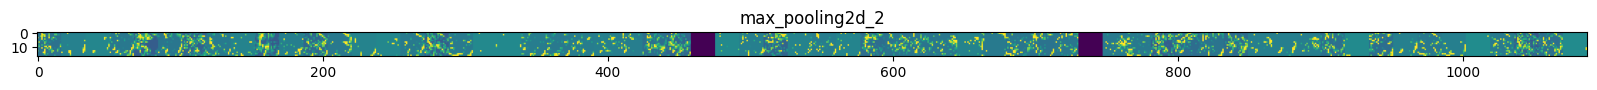

In [18]:
import numpy as np
import random
from tensorflow.keras.preprocessing.image import img_to_array, load_img

# Let's define a new Model that will take an image as input, and will output
# intermediate representations for all layers in the previous model after
# the first.
successive_outputs = [layer.output for layer in model.layers[1:]]
visualization_model = Model(img_input, successive_outputs)

# Let's prepare a random input image of a cat or dog from the training set.
cat_img_files = [os.path.join(train_cats_dir, f) for f in train_cat_fnames]
dog_img_files = [os.path.join(train_dogs_dir, f) for f in train_dog_fnames]
img_path = random.choice(cat_img_files + dog_img_files)

img = load_img(img_path, target_size=(150, 150))  # this is a PIL image
x = img_to_array(img)  # Numpy array with shape (150, 150, 3)
x = x.reshape((1,) + x.shape)  # Numpy array with shape (1, 150, 150, 3)

# Rescale by 1/255
x /= 255

# Let's run our image through our network, thus obtaining all
# intermediate representations for this image.
successive_feature_maps = visualization_model.predict(x)

# These are the names of the layers, so can have them as part of our plot
layer_names = [layer.name for layer in model.layers[1:]]

# Now let's display our representations
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
  if len(feature_map.shape) == 4:
    # Just do this for the conv / maxpool layers, not the fully-connected layers
    n_features = feature_map.shape[-1]  # number of features in feature map
    # The feature map has shape (1, size, size, n_features)
    size = feature_map.shape[1]
    # We will tile our images in this matrix
    display_grid = np.zeros((size, size * n_features))
    for i in range(n_features):
      # Postprocess the feature to make it visually palatable
      x = feature_map[0, :, :, i]
      x -= x.mean()
      x /= x.std()
      x *= 64
      x += 128
      x = np.clip(x, 0, 255).astype('uint8')
      # We'll tile each filter into this big horizontal grid
      display_grid[:, i * size : (i + 1) * size] = x
    # Display the grid
    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')

As you can see we go from the raw pixels of the images to increasingly abstract and compact representations. The representations downstream start highlighting what the network pays attention to, and they show fewer and fewer features being "activated"; most are set to zero. This is called "sparsity." Representation sparsity is a key feature of deep learning.


These representations carry increasingly less information about the original pixels of the image, but increasingly refined information about the class of the image. You can think of a convnet (or a deep network in general) as an information distillation pipeline.

### Evaluating Accuracy and Loss for the Model

Let's plot the training/validation accuracy and loss as collected during training:

Text(0.5, 1.0, 'Training and validation loss')

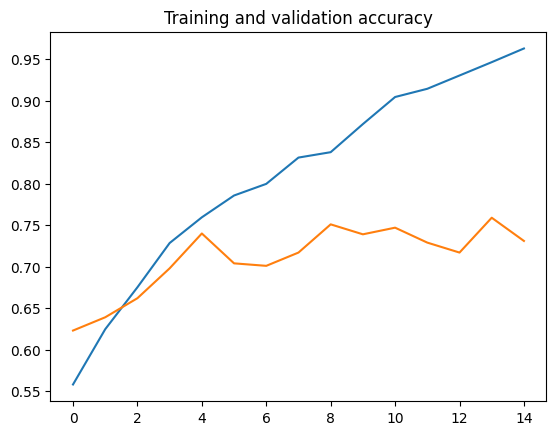

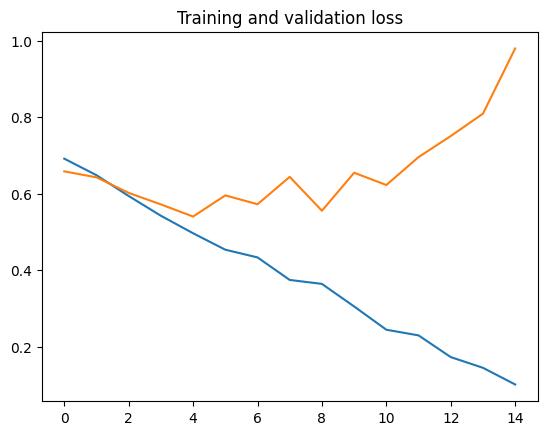

In [19]:
# Retrieve a list of accuracy results on training and validation data
# sets for each training epoch
acc = history.history['acc']
val_acc = history.history['val_acc']

# Retrieve a list of list results on training and validation data
# sets for each training epoch
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get number of epochs
epochs = range(len(acc))

# Plot training and validation accuracy per epoch
plt.plot(epochs, acc)
plt.plot(epochs, val_acc)
plt.title('Training and validation accuracy')

plt.figure()

# Plot training and validation loss per epoch
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.title('Training and validation loss')

As you can see, we are **overfitting** like it's getting out of fashion. Our training accuracy (in blue) gets close to 100% (!) while our validation accuracy (in orange) stalls as 70%. Our validation loss reaches its minimum after only five epochs.

Since we have a relatively small number of training examples (2000), overfitting should be our number one concern. Overfitting happens when a model exposed to too few examples learns patterns that do not generalize to new data, i.e. when the model starts using irrelevant features for making predictions. For instance, if you, as a human, only see three images of people who are lumberjacks, and three images of people who are sailors, and among them the only person wearing a cap is a lumberjack, you might start thinking that wearing a cap is a sign of being a lumberjack as opposed to a sailor. You would then make a pretty lousy lumberjack/sailor classifier.

Overfitting is the central problem in machine learning: given that we are fitting the parameters of our model to a given dataset, how can we make sure that the representations learned by the model will be applicable to data never seen before? How do we avoid learning things that are specific to the training data?

In the next exercise, we'll look at ways to prevent overfitting in the cat vs. dog classification model.

# Model Evasion

## Exercise 2: Creating an adversarial scenario

**Estimated completion time: 30 minutes**

In this exercise, we will be magicians and transform a cat into a dog and dog into a cat, or at least according to the CNN. We will us three techniques to do so, two black box attacks and one white box attack.


Let's select the first batch and the first image and label in the batch. Check  
1. that the image is correctly labeled for the attack to be real.
2. that the prediction is not perfectly equal to the label (it can make the black box attack harder)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Image label: 1.0
Predicted label: [0.9987241]


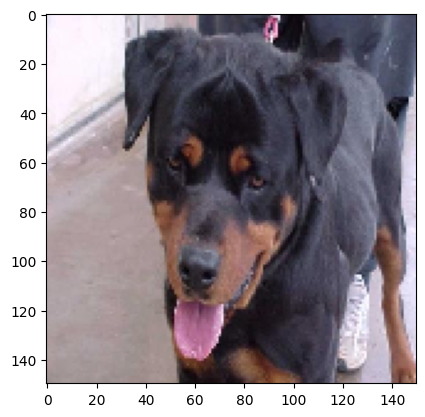

In [ ]:
# Try running this cell a few times to check if the model is accurate for detecting cats from dogs.
# If label = 0 : cat
# if label = 1 : Dog

image_batch = next(validation_generator)
first_image = image_batch[0][0]
first_label = image_batch[1][0]  # true label from data


predicted_label = model.predict(image_batch[0])[0]  # predicted label
plt.imshow(first_image)
print(f'Image label: {first_label}')
print(f'Predicted label: {predicted_label}')

### Black box attack, gradient ascent
Let's create an attack function that will modify the image until it has the wrong label.
1. Read the code and understand how it works.
2. Modify it to reduce the amplitude of the modification that will generate the error.

Goal 0.0
First prediction 0.9987241
-------------------------------
Iteration 0
Delta sum 0.0
New prediction 0.9986287355422974
Better solution found, delta incremented
Current prediction 0.9986287355422974
-------------------------------
Iteration 1
Delta sum 1.2000000000000002
New prediction 0.9985426664352417
Better solution found, delta incremented
Current prediction 0.9985426664352417
-------------------------------
Iteration 2
Delta sum -3.6000000000000005
New prediction 0.9984778165817261
Better solution found, delta incremented
Current prediction 0.9984778165817261
-------------------------------
Iteration 3
Delta sum -3.6000000000000005
New prediction 0.9985077977180481
Current prediction 0.9984778165817261
-------------------------------
Iteration 4
Delta sum -3.6000000000000005
New prediction 0.9984384179115295
Better solution found, delta incremented
Current prediction 0.9984384179115295
-------------------------------
Iteration 5
Delta sum -2.4000000000000004
New predictio

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2784313648939133..1.3921569228172301].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4..0.4].


New prediction 0.5169972777366638
Current prediction 0.5001377463340759
-------------------------------
Iteration 239
Delta sum 14.400000000000006
New prediction 0.5275726318359375
Current prediction 0.5001377463340759
-------------------------------
Iteration 240
Delta sum 14.400000000000006
New prediction 0.48250308632850647
Better solution found, delta incremented
Current prediction 0.48250308632850647
Attack succesful


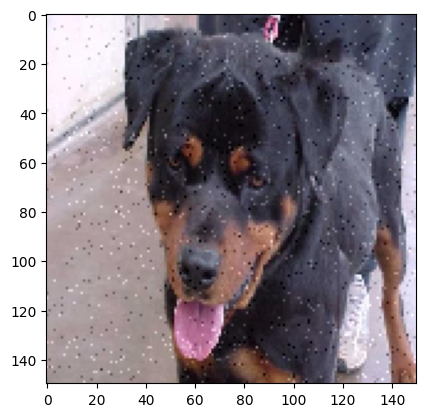

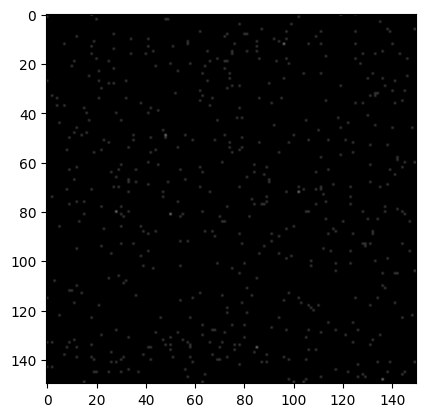

In [33]:
def evasion_attack1(
    image,
    model,
    goal,
    nbr_iter_max=1000,
    epsilon=[0.2, 0.2, 0.2],
    threshold=100,
    positions=10,
    verbose=True
):
    # 1) Small helper: print only when verbose=True.
    print_verbose = lambda msg: verbose and print(msg)

    # 2) Show the target class we want the attack to reach.
    print("Goal", goal)

    # 3) Read the image dimensions.
    #    width = image height in pixels, hight = image width in pixels, _ = color channels.
    width, hight, _ = image.shape

    # 4) Start with no perturbation at all.
    #    delta will store the small pixel changes we add to the image.
    delta = np.zeros((image.shape))

    # 5) Get the model's original prediction for the unmodified image.
    #    model.predict(...) returns a 2D array, so [0][0] extracts the scalar probability.
    prediction = model.predict(np.array([image]), verbose=0)[0][0]

    # 6) Display the starting prediction.
    print("First prediction", prediction)

    # 7) If the image already matches the goal well enough, warn the user.
    #    abs(prediction - goal) < 0.5 means the model is already on the target side.
    if abs(prediction - goal) < 0.5:
        print("Image already has the right label")

    # 8) Initialize the iteration counter.
    nbr_iter = 0

    # 9) Keep looping while:
    #    - the total perturbation stays below the threshold
    #    - and we have not exceeded the maximum number of iterations
    while np.sum(delta) < threshold and nbr_iter < nbr_iter_max:
        print_verbose(f"-------------------------------")
        print_verbose(f"Iteration {nbr_iter}")
        print_verbose(f"Delta sum {np.sum(delta)}")

        # 10) Randomly choose pixel positions to modify.
        coordinates = []
        for i in range(positions):
            coordinates.append((np.random.randint(width), np.random.randint(hight)))

        # 11) Make a copy of the current perturbation so we can test a new candidate.
        new_delta = delta.copy()

        # 12) For each chosen pixel, add or subtract epsilon randomly.
        #     This creates a new candidate perturbation.
        for coordinate in coordinates:
            new_delta[coordinate] = (
                new_delta[coordinate] + epsilon
                if np.random.random(1) > 0.5
                else new_delta[coordinate] - epsilon
            )

        # 13) Apply the candidate perturbation to the image.
        delta_image = image.copy() + new_delta

        # 14) Ask the model to predict the modified image.
        new_prediction = model.predict(np.array([delta_image]), verbose=0)[0][0]
        print_verbose(f"New prediction {new_prediction}")

        # 15) Keep the new perturbation only if it moves the prediction closer to the goal.
        if abs(new_prediction - goal) < abs(prediction - goal):
            print_verbose("Better solution found, delta incremented")
            prediction = new_prediction
            delta = new_delta

        # 16) Show the prediction after this iteration.
        print_verbose(f"Current prediction {prediction}")

        # 17) Increment the loop counter.
        nbr_iter += 1

        # 18) If the prediction is now close enough to the goal, stop the attack.
        if abs(prediction - goal) < 0.5:
            print("Attack succesful")
            plt.figure()
            plt.imshow(delta_image)
            plt.figure()
            plt.imshow(delta)
            return (delta_image, new_delta)

    # 19) If the loop finishes without success, return placeholders.
    return (_, _)

attack_image, delta = evasion_attack1(first_image, model, (first_label+1)%2, verbose=True)

### Black box attack, mixing images

For this attack we are going to create a vector between the image and a reference image with the other label. Then we will progressively move the image towards this reference image until we cross the 0.5 that will lead to the wrong classification of the image.
1. How well does it work?
2. How to improve it?

Goal 0.0
First prediction 0.9987241
Cats dir contents : ['82.jpg', '820.jpg', '8200.jpg', '8201.jpg', '8202.jpg', '8203.jpg', '8204.jpg', '8205.jpg', '8206.jpg', '8207.jpg', '8208.jpg', '8209.jpg', '821.jpg', '8210.jpg', '8211.jpg', '8212.jpg', '8213.jpg', '8214.jpg', '8215.jpg', '8216.jpg', '8217.jpg', '8218.jpg', '8219.jpg', '822.jpg', '8220.jpg', '8221.jpg', '8222.jpg', '8223.jpg', '8224.jpg', '8225.jpg', '8226.jpg', '8227.jpg', '8228.jpg', '8229.jpg', '823.jpg', '8230.jpg', '8231.jpg', '8232.jpg', '8233.jpg', '8234.jpg', '8235.jpg', '8236.jpg', '8237.jpg', '8238.jpg', '8239.jpg', '824.jpg', '8240.jpg', '8241.jpg', '8242.jpg', '8243.jpg', '8244.jpg', '8245.jpg', '8246.jpg', '8247.jpg', '8248.jpg', '8249.jpg', '825.jpg', '8250.jpg', '8251.jpg', '8252.jpg', '8253.jpg', '8254.jpg', '8255.jpg', '8256.jpg', '8257.jpg', '8258.jpg', '8259.jpg', '826.jpg', '8260.jpg', '8261.jpg', '8262.jpg', '8263.jpg', '8264.jpg', '8265.jpg', '8266.jpg', '8267.jpg', '8268.jpg', '8269.jpg', '827.jpg', '8270

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3606216993464052..0.30208669010908057].


Attack successful


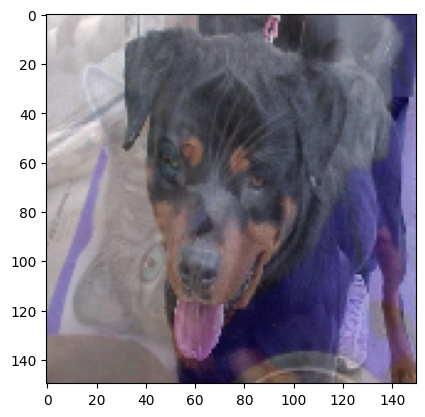

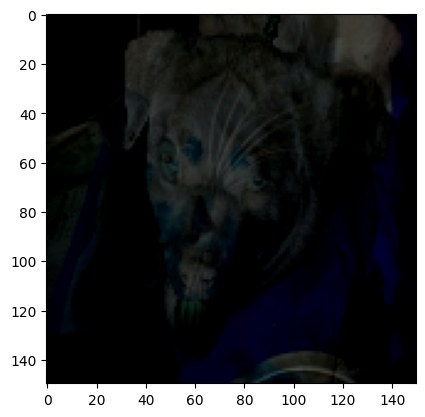

In [50]:
# Slowly turn the dog image into a cat image incrementally until we find the point where the predicition flips !


def evasion_attack2(image, model, goal, nbr_iter=1000, verbose=True):
    # 1) Helper function: prints messages only if verbose=True.
    print_verbose = lambda msg: verbose and print(msg)

    # 2) Display the target class we want the model to predict.
    print("Goal", goal)
    width, hight, _ = image.shape

    # 4) Get the model's prediction for the original image.
    #    The output is a probability, so [0][0] extracts the scalar value.
    prediction = model.predict(np.array([image]), verbose=0)[0][0]

    # 5) Print the starting prediction.
    print("First prediction", prediction)

    # 6) Choose a reference image from the opposite class.
    #    If the current prediction is 0.0, use a cat image; otherwise use a dog image.
    print(f'Cats dir contents : {os.listdir(train_cats_dir)[:]}')
    print(f'Dogs dir contents : {os.listdir(train_dogs_dir)[:]}')
    if goal == 0.0:
        opposite_image_path = os.path.join(train_cats_dir, '8299.jpg')
        
    else:
        opposite_image_path = os.path.join(train_dogs_dir, '8299.jpg')

    # 7) Load the reference image and scale its pixel values to [0, 1].
    opposite_image = cv2.imread(opposite_image_path) / 255

    # 8) Resize the reference image so it matches the current image size.
    opposite_image = cv2.resize(opposite_image, (width, hight))

    # 9) Compute the full difference between the opposite-class image and the original image.
    #    This is the total direction we will travel.
    full_delta = opposite_image - image

    # 10) If the image already matches the goal, stop immediately.
    if abs(prediction - goal) < 0.5:
        print("The image already has the right label")
        return (_, _)

    # 11) Gradually increase the amount of the delta we apply.
    for iter in range(nbr_iter):
        print_verbose(f"-------------------------------")
        print_verbose(f"Iteration {iter}")

        # 12) Scale the full delta by the current progress ratio.
        #     Early iterations apply a small change; later iterations apply more.
        delta = (iter / nbr_iter) * full_delta

        # 13) Add the perturbation to the original image.
        delta_image = image + delta

        # 14) Ask the model to classify the modified image.
        prediction = model.predict(np.array([delta_image]), verbose=0)[0][0]
        print_verbose(f"New prediction {prediction}")

        # 15) If the modified image now fools the model, stop and return it.
        if abs(prediction - goal) < 0.5:
            print("Attack successful")
            plt.figure()
            plt.imshow(delta_image)
            plt.figure()
            plt.imshow(delta, cmap='hot')
            return (delta_image, delta)

    # 16) If no successful attack was found, report failure.
    print("Attack unsuccessful")
    return (_, _)

# 17) Run the attack on the chosen image, targeting the opposite class.
attack_image, delta = evasion_attack2(first_image, model, (first_label + 1) % 2, verbose=False)

## White box attack, Fast Gradient Sign Method

The fast gradient sign method works by using the gradients of the neural network to create an adversarial example. For an input image, the method uses the gradients of the loss with respect to the input image to create a new image that maximises the loss. This new image is called the adversarial image. This can be summarised using the following expression:
$$adv\_x = x + \epsilon*\text{sign}(\nabla_xJ(\theta, x, y))$$

where

*   adv_x : Adversarial image.
*   x : Original input image.
*   y : Original input label.
*   $\epsilon$ : Multiplier to ensure the perturbations are small.
*   $\theta$ : Model parameters.
*   $J$ : Loss.

[source](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/generative/adversarial_fgsm.ipynb#scrollTo=8dn1-g8BpPDx)



1.   Compare its deformation with previous attacks
2.   Can you improve the implementation?



-------------------------------
Epsilon 0
New prediction 0.998724102973938
Attack unsuccessful
-------------------------------
Epsilon 0.01
New prediction 0.005331237334758043
Attack successful


'\nHow to interpret the result\n    If the original image was classified correctly, FGSM tries to make a tiny change that flips the prediction.\n    The image may still look almost identical to humans.\n    But the model can become wrong very quickly.\n\nCompared with the black-box attacks\n    Attack 1: random pixel nudges\n    Attack 2: move toward an opposite-class image\n    Attack 3 / FGSM: use gradients to directly find the most effective direction\n    So FGSM is usually:\n      - faster,\n      - more precise,\n      - and more powerful,\n    because it uses the model’s internal gradient information.\n\n'

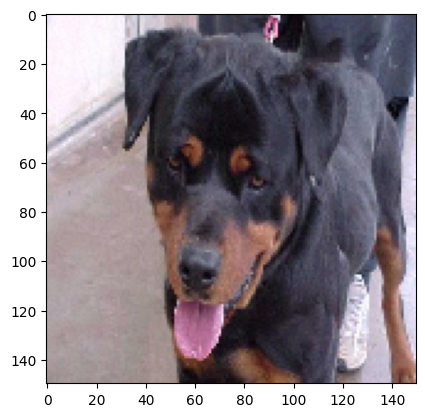

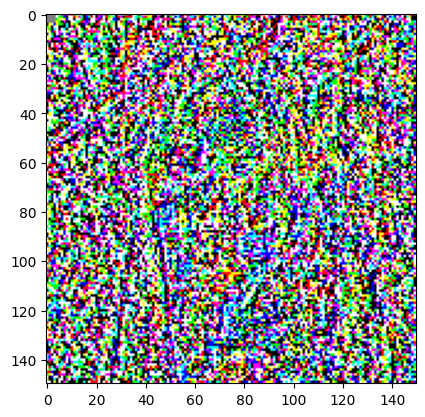

In [53]:
"""
    Adversarial Image :
      - uses the gradient of the loss with respect to the input image.
      - That tells you which pixels to change, and in which direction, to increase the model’s error.


    White Box :
      - needs access to the model, loss and the gradients.
      - Black box means we only have access to the input/output
      - White box
"""


import tensorflow as tf
loss_object = tf.keras.losses.BinaryCrossentropy()   # Creates the loss function used by the model.

def evasion_attack3(
      input_image,       # original image
      model,             # the classifier
      input_label,       # the true label
      goal               # fake label the model should end up predicting
  ):
  input_image = tf.cast(input_image, tf.float32)  # Converts image and label to floating-point tensors.
  input_label = tf.cast(input_label, tf.float32)
  input_image = tf.expand_dims(input_image, axis=0) # add batch dim : The model expects input shape like [batch, height, width, channels].
  input_label = tf.expand_dims(input_label, axis=0)
  
  with tf.GradientTape() as tape:               #  records operations so TensorFlow can compute gradients.
    tape.watch(input_image)                     #  tells TensorFlow to track the image itself.
    prediction = model(input_image)             #  model output for the current image.
    loss = loss_object(input_label, prediction) #  measures how wrong the prediction is.


  gradient = tape.gradient(loss, input_image)   # Computes how the loss changes if each pixel changes a little.
  signed_grad = tf.sign(gradient)               # Keeps only the sign of each gradient value (Positive means “increase this pixel.”, Negative means “decrease this pixel.”)
  epsilons = [0, 0.01, 0.02, 0.03, 0.04, 0.1, 0.15, 0.25]  # Tries several perturbation sizes.

  # Try out perturbations based on the gradient
  for eps in epsilons:
    print(f"-------------------------------")
    print(f"Epsilon {eps}")

    delta=eps*signed_grad                              # Builds perturbation
    delta_image = input_image + delta                  # Add to original image
    delta_image = tf.clip_by_value(delta_image, 0, 1)  # clip pixel value to [0, 1]

    # runs the model on the modified image.
    prediction = model.predict(delta_image, verbose=0)[0][0]     
    print(f"New prediction {prediction}") 

    #Stop if the modified image passed the API
    if abs(prediction-goal)<0.5:
        print("Attack successful")
        plt.figure()
        plt.imshow(delta_image[0])
        plt.figure()
        plt.imshow(signed_grad[0]*0.5 + 0.5, cmap='hot')
        return (delta_image, delta )
    print("Attack unsuccessful")
  return (_,_)

attack_image, delta = evasion_attack3(first_image, model,first_label, (first_label+1)%2)



"""
How to interpret the result
    If the original image was classified correctly, FGSM tries to make a tiny change that flips the prediction.
    The image may still look almost identical to humans.
    But the model can become wrong very quickly.

Compared with the black-box attacks
    Attack 1: random pixel nudges
    Attack 2: move toward an opposite-class image
    Attack 3 / FGSM: use gradients to directly find the most effective direction
    So FGSM is usually:
      - faster,
      - more precise,
      - and more powerful,
    because it uses the model’s internal gradient information.

"""


# Membership inference
Let's now check if we can find a way to establish if an image was used to train the model. We will generate the histograms of the predictions for the validation and the training set.
1. What do you notice?
2. Based on the prediction value can you establish with some certainty if an image was used during training?
3. How to avoid that here?apply it.

In [54]:
# Function to generate predictions from a generator
def generate_predictions(generator, model):
    predictions = []
    for _ in range(len(generator)):
        batch_data = next(generator)
        batch_predictions = model.predict(batch_data[0], verbose=0)
        predictions.extend(batch_predictions.flatten())
    return np.array(predictions)

# Generate predictions for both generators
predictions1 = generate_predictions(validation_generator, model)
predictions2 = generate_predictions(train_generator, model)



/home/vass/dev/AILabs/MachineLearningLabs_4eiai40/.mlproject2026/lib64/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [ ]:
# Plot histograms for both sets of predictions on the same figure
plt.figure(figsize=(4, 3))

# Plot histogram for predictions from generator1 (in blue)
plt.hist(predictions1, bins=50, range=(0, 1), color='blue', alpha=0.5, label='Validation set predictions')

# Add labels and legend
plt.title('Histogram of Model Predictions')
plt.xlabel('Predicted Values')
plt.ylabel('Frequency')
plt.legend()
plt.yscale("log")
# Show grid
plt.grid(True)

plt.figure(figsize=(4, 3))
# Plot histogram for predictions from generator2 (in orange)
plt.hist(predictions2, bins=50, range=(0, 1), color='orange', alpha=0.5, label='Training set predictions')

# Add labels and legend
plt.title('Histogram of Model Predictions')
plt.xlabel('Predicted Values')
plt.ylabel('Frequency')
plt.legend()
plt.yscale("log")
# Show grid
plt.grid(True)

# Show the plot
plt.show()

# Data poisoning

Exercice 3: Add a trigger to induce an error

Let's poison the dataset by setting a blue square at the top left of all the dogs image in the dataset and retrain the model. The model will now use the blue square to discriminate dog and cats and not the rest of the image. We have an issue as the model is not able to differentiate dogs and cats at all.


1.   Fix this issue. hint: you might need to reaload the original dataset
2.   What's th impact on performances?
3.   Change the blue square for a trigger that is invisble to the human eye

In [ ]:
def hiddenprocess(img):
    img[:15,:15] = (255,0,0)
    return img

train_dog_fnames = os.listdir(train_dogs_dir)

for fname in train_dog_fnames:
  full_path = os.path.join(train_dogs_dir, fname)
  img = cv2.imread(full_path)
  cv2.imwrite(full_path,hiddenprocess(img))

In [ ]:
image_batch = next(train_generator)
first_image = image_batch[0][0]
plt.imshow(first_image)

Let's retrain the model

In [ ]:
model2 = Model(img_input, output)
model2.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=0.001),
              metrics=['acc'])
history = model2.fit(
      train_generator,
      steps_per_epoch=100,  # 2000 images = batch_size * steps
      epochs=15,
      validation_data=validation_generator,
      validation_steps=50,  # 1000 images = batch_size * steps
      verbose=2)

Let's add a blue square at the top left of a cat picture and show if it is correcty classified. You might need to reiterate mutliple times in order to have a cat that is correctly predicted for the first model and wrongly by the second.

In [ ]:
image_batch = next(validation_generator)
image = image_batch[0][0]
label = image_batch[1][0]
predicted_label = model.predict(image_batch[0])[0]
plt.figure()
plt.title(f'Image label: {label}  Predicted label: {predicted_label}')
plt.imshow(image)

def hiddenprocess2(img):
    img[:15,:15] = (0,0,255)
    return img

trigered_image = hiddenprocess2(image)
plt.figure()
trigered_predicted_label = model2.predict(np.array([trigered_image,]))[0]
plt.title(f'Image label: {label}  Poisoined model predicted label: {trigered_predicted_label}')
plt.imshow(trigered_image)

# Prompt injection
Trick the LLM into revealing its secret https://gandalf.lakera.ai/baseline

## Clean Up

Before running the next exercise, run the following cell to terminate the kernel and free memory resources: